# Milestone 3 (v0.2) — Self-Supervised Pre-Training


In [1]:
import sys, json, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
ROOT = Path.cwd()
sys.path.insert(0, str(ROOT))

from gridfm import dataset as ds, encoding as enc, train as tr
from gridfm.model import GridFMv02, count_parameters

PROC_DIR = ROOT / "data" / "processed"
CKPT_DIR = ROOT / "checkpoints"
FIG_DIR = ROOT / "results" / "figures" / "v02_m3"
STATS_DIR = ROOT / "results" / "v02_m3_stats"
for d in [FIG_DIR, STATS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

PRETRAIN_GRIDS = ["case24", "case30", "case118"]
EPOCHS, SEED, LR = 300, 42, 1e-4
device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(SEED)

train_loader, val_loader = tr.make_loaders(PROC_DIR, PRETRAIN_GRIDS, batch_size=64,
                                           seed=SEED, transform=enc.concat_rwpe)
model = GridFMv02()
print("device: %s%s | params: %s | train graphs: %d | val graphs: %d"
      % (device, " (%s)" % torch.cuda.get_device_name(0) if device == "cuda" else "",
         format(count_parameters(model), ","),
         len(train_loader.dataset), len(val_loader.dataset)))

config = {"grids": PRETRAIN_GRIDS, "epochs": EPOCHS, "batch_size": 64, "lr": LR,
          "clip": 1.0, "sched": "ReduceLROnPlateau(0.7, 10)", "w1": 0.01, "w2": 0.99,
          "model": {"arch": "GPSConv+GINEConv", "hidden": 80, "heads": 4,
                    "num_layers": 4, "dropout": 0.1, "in_dim": 25, "rwpe_k": enc.K_STEPS},
          "seed": SEED, "device": device}
with open(STATS_DIR / "config.json", "w") as f:
    json.dump(config, f, indent=2)
print(json.dumps(config["model"]))

device: cuda (NVIDIA GeForce RTX 3050 Laptop GPU) | params: 270,806 | train graphs: 4374 | val graphs: 547
{"arch": "GPSConv+GINEConv", "hidden": 80, "heads": 4, "num_layers": 4, "dropout": 0.1, "in_dim": 25, "rwpe_k": 16}


## The run

In [2]:
history = tr.fit(model, train_loader, val_loader, epochs=EPOCHS, ckpt_dir=CKPT_DIR,
                 device=device, lr=LR, clip=config["clip"],
                 resume=True, log_every=10, tag="pretrain_v02")
history.to_csv(STATS_DIR / "history.csv", index=False)
best = history.loc[history.val_total.idxmin()]
print("\nbest validation loss %.4f at epoch %d | total wall time %.1f min"
      % (best.val_total, int(best.epoch), history.time_s.sum() / 60))

epoch   0 | train 46.8996 (mse 0.1218 pbe 47.3721) | val 21.5439 | lr 1.0e-04 | 4s


epoch  10 | train 0.9016 (mse 0.0116 pbe 0.9106) | val 0.3330 | lr 1.0e-04 | 4s


epoch  20 | train 0.3562 (mse 0.0081 pbe 0.3597) | val 0.2050 | lr 1.0e-04 | 4s


epoch  30 | train 0.2406 (mse 0.0068 pbe 0.2430) | val 0.2012 | lr 1.0e-04 | 3s


epoch  40 | train 0.1784 (mse 0.0059 pbe 0.1802) | val 0.1260 | lr 1.0e-04 | 4s


...

epoch 260 | train 0.0350 (mse 0.0026 pbe 0.0354) | val 0.0286 | lr 2.4e-05 | 4s


epoch 270 | train 0.0349 (mse 0.0026 pbe 0.0353) | val 0.0309 | lr 2.4e-05 | 4s


epoch 280 | train 0.0320 (mse 0.0025 pbe 0.0323) | val 0.0280 | lr 1.7e-05 | 4s


epoch 290 | train 0.0322 (mse 0.0025 pbe 0.0325) | val 0.0269 | lr 1.7e-05 | 4s


epoch 299 | train 0.0331 (mse 0.0025 pbe 0.0334) | val 0.0269 | lr 1.7e-05 | 4s

best validation loss 0.0266 at epoch 297 | total wall time 19.3 min


## Training curves — v0.2 against the v0.1 run

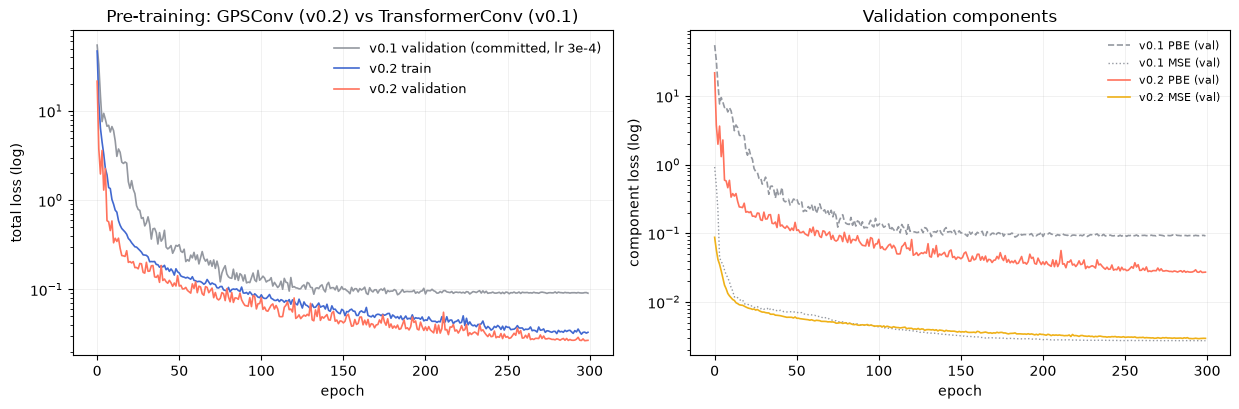

val loss floor:   v0.1 0.0871 (epoch 183)   v0.2 0.0266 (epoch 297)
final-epoch val:  v0.1 0.0907              v0.2 0.0269


In [3]:
h01 = pd.read_csv(ROOT / "results" / "m4_stats" / "history.csv")   # committed v0.1

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.2))
axes[0].plot(h01.epoch, h01.val_total, color="#9498A0", lw=1.2,
             label="v0.1 validation (committed, lr 3e-4)")
axes[0].plot(history.epoch, history.train_total, color="#4269D0", lw=1.2, label="v0.2 train")
axes[0].plot(history.epoch, history.val_total, color="#FF725C", lw=1.2, label="v0.2 validation")
axes[0].set_yscale("log")
axes[0].set(xlabel="epoch", ylabel="total loss (log)",
            title="Pre-training: GPSConv (v0.2) vs TransformerConv (v0.1)")
axes[0].legend(frameon=False, fontsize=9)

axes[1].plot(h01.epoch, h01.val_pbe, color="#9498A0", lw=1.2, ls="--", label="v0.1 PBE (val)")
axes[1].plot(h01.epoch, h01.val_mse, color="#9498A0", lw=1.0, ls=":", label="v0.1 MSE (val)")
axes[1].plot(history.epoch, history.val_pbe, color="#FF725C", lw=1.2, label="v0.2 PBE (val)")
axes[1].plot(history.epoch, history.val_mse, color="#EFB118", lw=1.2, label="v0.2 MSE (val)")
axes[1].set_yscale("log")
axes[1].set(xlabel="epoch", ylabel="component loss (log)", title="Validation components")
axes[1].legend(frameon=False, fontsize=8)
for ax in axes:
    ax.grid(alpha=0.25, lw=0.5)
fig.tight_layout(); fig.savefig(FIG_DIR / "f1_training_curves.png", bbox_inches="tight", dpi=150)
plt.show()

print("val loss floor:   v0.1 %.4f (epoch %d)   v0.2 %.4f (epoch %d)"
      % (h01.val_total.min(), int(h01.loc[h01.val_total.idxmin()].epoch),
         history.val_total.min(), int(best.epoch)))
print("final-epoch val:  v0.1 %.4f              v0.2 %.4f"
      % (h01.val_total.iloc[-1], history.val_total.iloc[-1]))

## The learning-rate schedule and the cost of attention

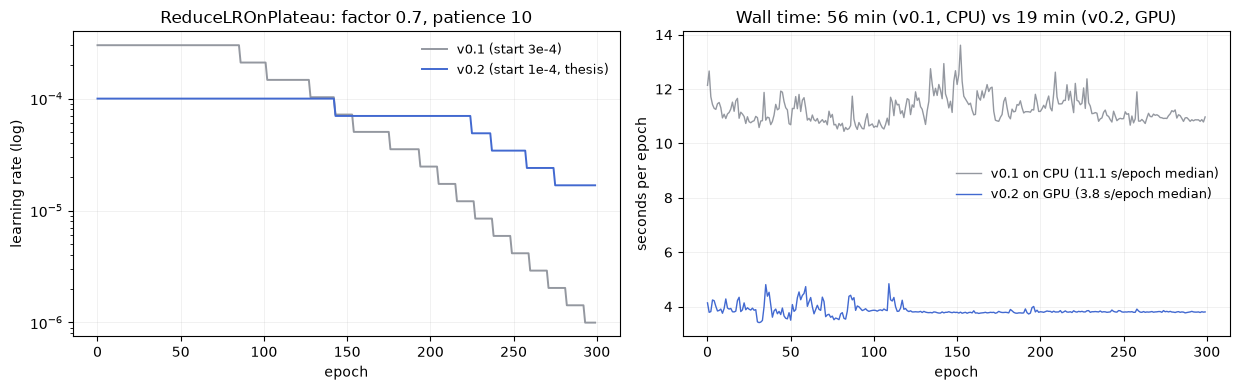

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.0))
axes[0].plot(h01.epoch, h01.lr, color="#9498A0", lw=1.4, label="v0.1 (start 3e-4)")
axes[0].plot(history.epoch, history.lr, color="#4269D0", lw=1.4, label="v0.2 (start 1e-4, thesis)")
axes[0].set_yscale("log")
axes[0].set(xlabel="epoch", ylabel="learning rate (log)",
            title="ReduceLROnPlateau: factor 0.7, patience 10")
axes[0].legend(frameon=False, fontsize=9)

axes[1].plot(h01.epoch, h01.time_s, color="#9498A0", lw=1.0,
             label="v0.1 on CPU (%.1f s/epoch median)" % h01.time_s.median())
axes[1].plot(history.epoch, history.time_s, color="#4269D0", lw=1.0,
             label="v0.2 on GPU (%.1f s/epoch median)" % history.time_s.median())
axes[1].set(xlabel="epoch", ylabel="seconds per epoch",
            title="Wall time: %.0f min (v0.1, CPU) vs %.0f min (v0.2, GPU)"
                  % (h01.time_s.sum() / 60, history.time_s.sum() / 60))
axes[1].legend(frameon=False, fontsize=9)
for ax in axes:
    ax.grid(alpha=0.25, lw=0.5)
fig.tight_layout(); fig.savefig(FIG_DIR / "f2_lr_and_time.png", bbox_inches="tight", dpi=150)
plt.show()

## Before / after: the Milestone-2 teaser scenario, revisited

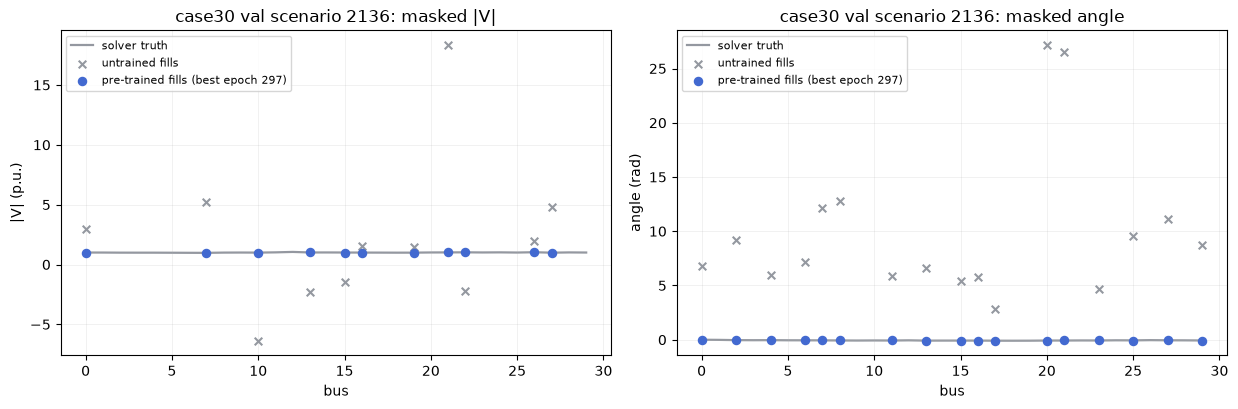

masked-slot MAE, pre-trained: |V| 0.0026 p.u. (M2 10-epoch: 0.0320), angle 0.0038 rad (M2: 0.0191)
{
  "best_val": 0.02661655848025186,
  "best_epoch": 297,
  "final_val": 0.02688947437293623,
  "wall_min": 19.284463421503702,
  "sec_per_epoch_median": 3.801896572113037,
  "v01_best_val": 0.0871243303474822,
  "v01_best_epoch": 183,
  "v01_wall_min": 56.134202829996745,
  "teaser_mae": {
    "vm_pu": 0.0026322442572563887,
    "va_rad": 0.003831465495750308
  }
}


In [5]:
# val_loader.dataset here is the concatenated 3-grid list, so index 7 would be a
# case24 graph; load case30 val directly to hit the exact M2 teaser scenario
case30_val = enc.concat_rwpe(ds.load_processed(PROC_DIR, "case30", "val"))
g = case30_val[7].clone()
gen = torch.Generator().manual_seed(7)
xm_c, m_c = ds.random_mask(g.x, generator=gen)
g, xm, m = g.to(device), xm_c.to(device), m_c.to(device)

torch.manual_seed(SEED)
model_before = GridFMv02().to(device).eval()
model_after = GridFMv02().to(device).eval()
state = torch.load(CKPT_DIR / "final_pretrain_v02_best.pt", weights_only=False)
model_after.load_state_dict(state["model"])
with torch.no_grad():
    pred_b = model_before(xm, g.edge_index, g.edge_attr)
    pred_a = model_after(xm, g.edge_index, g.edge_attr)

buses = np.arange(g.num_nodes)
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.2))
for ax, col, name, unit in [(axes[0], 4, "|V|", "p.u."), (axes[1], 5, "angle", "rad")]:
    truth = g.x[:, col].cpu().numpy()
    mk = m[:, col].cpu().numpy().astype(bool)
    ax.plot(buses, truth, lw=1.6, color="#9498A0", label="solver truth", zorder=1)
    ax.scatter(buses[mk], pred_b.cpu().numpy()[mk, col], s=30, marker="x",
               color="#9498A0", zorder=2, label="untrained fills")
    ax.scatter(buses[mk], pred_a.cpu().numpy()[mk, col], s=34, color="#4269D0",
               zorder=3, label="pre-trained fills (best epoch %d)" % int(state["epoch"]))
    ax.set(xlabel="bus", ylabel="%s (%s)" % (name, unit),
           title="case30 val scenario %d: masked %s" % (int(g.scenario), name))
    ax.grid(alpha=0.25, lw=0.5); ax.legend(fontsize=8)
fig.tight_layout(); fig.savefig(FIG_DIR / "f3_before_after.png", bbox_inches="tight", dpi=150)
plt.show()

vm_mae = float((pred_a[m[:, 4], 4] - g.x[m[:, 4], 4]).abs().mean())
va_mae = float((pred_a[m[:, 5], 5] - g.x[m[:, 5], 5]).abs().mean())
print("masked-slot MAE, pre-trained: |V| %.4f p.u. (M2 10-epoch: 0.0320), "
      "angle %.4f rad (M2: 0.0191)" % (vm_mae, va_mae))

summary = {"best_val": float(history.val_total.min()), "best_epoch": int(best.epoch),
           "final_val": float(history.val_total.iloc[-1]),
           "wall_min": float(history.time_s.sum() / 60),
           "sec_per_epoch_median": float(history.time_s.median()),
           "v01_best_val": float(h01.val_total.min()),
           "v01_best_epoch": int(h01.loc[h01.val_total.idxmin()].epoch),
           "v01_wall_min": float(h01.time_s.sum() / 60),
           "teaser_mae": {"vm_pu": vm_mae, "va_rad": va_mae}}
with open(STATS_DIR / "summary.json", "w") as f:
    json.dump(summary, f, indent=2)
print(json.dumps(summary, indent=2))